# Task 4: Forecasting Access and Usage (2025-2027)
**Ethiopia Financial Inclusion Forecasting**

Forecasts two Global Findex-defined targets:
- **Access**: Account Ownership Rate (% of adults with an account at a financial institution or mobile money)
- **Usage**: Digital Payment Usage (% of adults who made or received a digital payment)

Given only 4-5 sparse historical points, this notebook favors transparent, simple methods over complex
ones that would overfit, and is explicit throughout about where uncertainty is large.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import statsmodels.api as sm

sys.path.insert(0, str(Path.cwd().parent))
from src.data_loader import load_unified_data, get_observations, get_events, get_impact_links, DataLoadError

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

try:
    df = load_unified_data(path=Path("../data/processed/enriched_dataset.csv"))
except DataLoadError as e:
    raise SystemExit(f"Could not load the enriched dataset: {e}")

obs = get_observations(df)
events = get_events(df)
links = get_impact_links(df)

def logistic_ramp_fraction(t_months, lag_months):
    """Fraction of full effect realized at t_months since an event (see Task 3 methodology)."""
    if t_months < 0:
        return 0.0
    L = max(lag_months, 0.5)
    k = 2.944 / L
    return 1 / (1 + np.exp(-k * (t_months - L)))

def months_between(d1, d2):
    return (d2.year - d1.year) * 12 + (d2.month - d1.month)

print("Data loaded. Building forecasts for 2025-2027.")

Data loaded. Building forecasts for 2025-2027.


## 1. Define Targets and Historical Data

In [2]:
acc = obs[(obs.indicator_code == 'ACC_OWNERSHIP') & (obs.gender == 'all') & (obs.location == 'national')].copy()
acc['observation_date'] = pd.to_datetime(acc['observation_date'])
acc = acc.sort_values('observation_date')
print("Account Ownership Rate (Access) -- full history:")
print(acc[['observation_date', 'value_numeric', 'source_name']].to_string(index=False))

usg = obs[(obs.indicator_code == 'USG_DIGITAL_PAYMENT') & (obs.gender == 'all')].copy()
print("\nDigital Payment Usage -- full history (only 2024 exists):")
print(usg[['observation_date', 'value_numeric', 'source_name', 'confidence']].to_string(index=False))

Account Ownership Rate (Access) -- full history:
observation_date  value_numeric        source_name
      2014-12-31           22.0 Global Findex 2014
      2017-12-31           35.0 Global Findex 2017
      2021-12-31           46.0 Global Findex 2021
      2024-11-29           49.0 Global Findex 2024

Digital Payment Usage -- full history (only 2024 exists):
observation_date  value_numeric                           source_name confidence
      2024-12-31           21.0 Global Findex 2025 (via Birr Metrics)        low


**A critical data-sparsity note, stated up front:** Access has 4 historical points spanning 2014-2024
(not the 5 points over 13 years the brief anticipates -- our dataset's earliest point is 2014, not 2011).
Usage has effectively **one** anchor point (2024) and zero historical trend at all. This fundamentally
shapes the approach: Access can support a trend regression; Usage cannot, and must instead be built
forward from its one baseline value using event effects, which the interpretation section flags as the
single biggest source of uncertainty in this task.

**Usage baseline choice:** the project brief defines Usage as "% of adults who made or received a digital
payment" (~35% in 2024, per the brief). The enriched dataset's own `USG_DIGITAL_PAYMENT` observation is
21% (Task 1 enrichment, flagged low-confidence -- a different Findex sub-metric, likely "used a digital
payment" among account holders rather than among all adults). Per the Task 2 data-quality recommendation,
**we use the brief's ~35% figure as the primary 2024 baseline** for this forecast, since it matches the
target's own definition, and treat the 21% figure only as a cross-check.

## 2. Select Approach

For **Access**: trend regression is feasible (4 points) but naive full-history OLS assumes constant
growth, which Task 2 showed is wrong -- growth decelerated from 4.33 to 2.75 to 1.00 pp/year across the
three intervals. We fit both, for comparison, and use the **recent-trend (2021-2024) rate as the primary
baseline**, since it's the most relevant to near-term (2025-2027) conditions.

For **Usage**: trend regression is not feasible (1 point). We use an **event-augmented model**: hold the
2024 baseline, add a small organic-growth assumption, and layer on the one impact_link that quantitatively
targets this indicator (NDPS 2.0 -> USG_DIGITAL_PAYMENT, from Task 3's association matrix).

Both indicators get **three scenarios** (pessimistic / base / optimistic), which do double duty as the
brief's requested scenario analysis *and* as a plain-language uncertainty range, given how thin the
statistical basis is for a formal confidence interval on Usage.

Full-history OLS slope: 2.71 pp/year (2014-2024 average)
Recent-trend (2021-2024) rate: 1.00 pp/year  <-- used as baseline


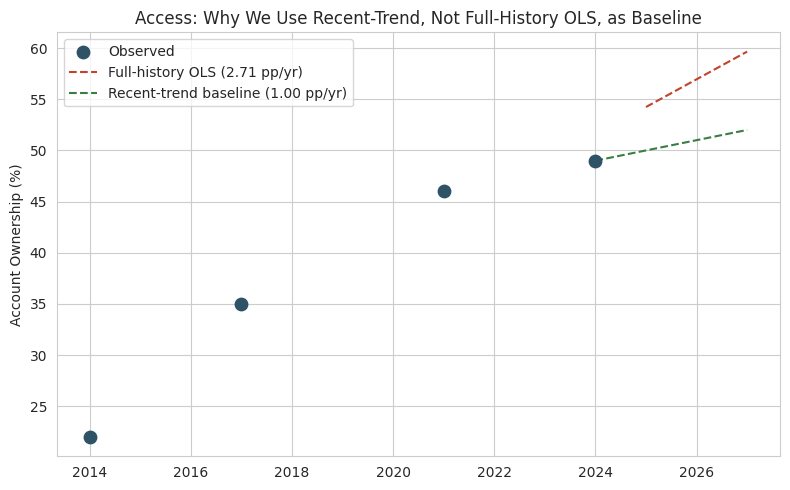

In [3]:
# Full-history OLS (for comparison) vs recent-trend baseline
years = acc['observation_date'].dt.year.values
values = acc['value_numeric'].values
X = sm.add_constant(years)
ols_full = sm.OLS(values, X).fit()
print(f"Full-history OLS slope: {ols_full.params[1]:.2f} pp/year (2014-2024 average)")

recent_rate = (49 - 46) / (2024 - 2021)
print(f"Recent-trend (2021-2024) rate: {recent_rate:.2f} pp/year  <-- used as baseline")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(years, values, s=80, color='#2E5266', zorder=3, label='Observed')
future_years = np.array([2025, 2026, 2027])
ax.plot(future_years, ols_full.predict(sm.add_constant(future_years, has_constant='add')),
        '--', color='#C1432E', label=f'Full-history OLS ({ols_full.params[1]:.2f} pp/yr)')
ax.plot([2024]+list(future_years), [49]+[49+recent_rate*(y-2024) for y in future_years],
        '--', color='#3A7D44', label=f'Recent-trend baseline ({recent_rate:.2f} pp/yr)')
ax.set_title("Access: Why We Use Recent-Trend, Not Full-History OLS, as Baseline")
ax.set_ylabel("Account Ownership (%)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "15_baseline_approach_comparison.png", bbox_inches='tight')
plt.show()

The full-history OLS line reaches **59.7% by 2027** -- driven almost entirely by the fast 2014-2021
growth spurt, which Task 2 showed has already ended. The recent-trend baseline (**52.0% by 2027**) is a
much more defensible "if nothing changes" starting point for the event-augmented forecast below.

## 3. Event-Augmented Forecast: Access (Account Ownership)

Using Task 3's logistic-ramp functional form and association matrix, we add the *incremental* (not yet
realized as of the 2024 baseline) effect of every event still ramping up during 2025-2027.

**Calibration note carried over from Task 3:** the one validated literature-based estimate (Telebirr's
effect on Account Ownership) overestimated the actual outcome by ~5x. We apply that lesson here: events
whose estimates are *not yet empirically validated* are scaled down by a **0.3x haircut** in the base
scenario, and used at full stated magnitude only in the optimistic scenario. This is a judgment call,
not a statistically derived factor -- documented explicitly rather than hidden in the numbers.

In [4]:
baseline_date = pd.Timestamp('2024-11-29')
forecast_dates = {2025: pd.Timestamp('2025-12-31'), 2026: pd.Timestamp('2026-12-31'), 2027: pd.Timestamp('2027-12-31')}

events_access = [
    dict(name="Telebirr Launch (Task-3-refined estimate)", date=pd.Timestamp('2021-05-17'), lag=12, magnitude=3.0, validated=True),
    dict(name="Fayda Digital ID Rollout", date=pd.Timestamp('2024-01-01'), lag=24, magnitude=10.0, validated=False),
    dict(name="NDPS 2.0 Launch", date=pd.Timestamp('2025-12-09'), lag=24, magnitude=3.0, validated=False),
]

def incremental_effect(event_list, multiplier_unvalidated, target_dates, base_date):
    out = {}
    for yr, fd in target_dates.items():
        total = 0.0
        for e in event_list:
            mult = 1.0 if e['validated'] else multiplier_unvalidated
            t_base = months_between(e['date'], base_date)
            t_fore = months_between(e['date'], fd)
            frac_b = logistic_ramp_fraction(t_base, e['lag'])
            frac_f = logistic_ramp_fraction(t_fore, e['lag'])
            total += e['magnitude'] * mult * (frac_f - frac_b)
        out[yr] = total
    return out

BASE_HAIRCUT = 0.3
base_incr = incremental_effect(events_access, BASE_HAIRCUT, forecast_dates, baseline_date)
opt_incr = incremental_effect(events_access, 1.0, forecast_dates, baseline_date)

access_forecast = pd.DataFrame({
    'year': [2025, 2026, 2027],
    'pessimistic': [round(49 + (recent_rate*0.5)*(y-2024), 1) for y in [2025,2026,2027]],
    'base': [round(49 + recent_rate*(y-2024) + base_incr[y], 1) for y in [2025,2026,2027]],
    'optimistic': [round(49 + recent_rate*(y-2024) + opt_incr[y], 1) for y in [2025,2026,2027]],
})
print(access_forecast.to_string(index=False))

 year  pessimistic  base  optimistic
 2025         49.5  51.0        53.3
 2026         50.0  53.1        58.0
 2027         50.5  54.8        61.4


## 4. Event-Augmented Forecast: Usage (Digital Payment Adoption)

Only one impact_link quantitatively targets `USG_DIGITAL_PAYMENT`: **IMP_0015 (NDPS 2.0, +10pp, medium
magnitude, 18-month lag, India-UPI analog, low confidence)**. We layer this on top of the 35% 2024
baseline plus a small organic-growth assumption (since no historical Usage trend exists to extrapolate).

In [5]:
usage_baseline = 35.0
ndps = dict(date=pd.Timestamp('2025-12-09'), lag=18, magnitude=10.0)
organic_growth = {'pessimistic': 0.3, 'base': 1.0, 'optimistic': 2.0}  # pp/year, deliberately modest

def ndps_incremental(mult, target_dates, base_date):
    out = {}
    for yr, fd in target_dates.items():
        t_base = months_between(ndps['date'], base_date)
        t_fore = months_between(ndps['date'], fd)
        out[yr] = ndps['magnitude'] * mult * (logistic_ramp_fraction(t_fore, ndps['lag']) - logistic_ramp_fraction(t_base, ndps['lag']))
    return out

usage_baseline_date = pd.Timestamp('2024-12-31')
base_ndps = ndps_incremental(BASE_HAIRCUT, forecast_dates, usage_baseline_date)
opt_ndps = ndps_incremental(1.0, forecast_dates, usage_baseline_date)
pess_ndps = ndps_incremental(0.0, forecast_dates, usage_baseline_date)

usage_forecast = pd.DataFrame({
    'year': [2025, 2026, 2027],
    'pessimistic': [round(usage_baseline + organic_growth['pessimistic']*(y-2024) + pess_ndps[y], 1) for y in [2025,2026,2027]],
    'base': [round(usage_baseline + organic_growth['base']*(y-2024) + base_ndps[y], 1) for y in [2025,2026,2027]],
    'optimistic': [round(usage_baseline + organic_growth['optimistic']*(y-2024) + opt_ndps[y], 1) for y in [2025,2026,2027]],
})
print(usage_forecast.to_string(index=False))

 year  pessimistic  base  optimistic
 2025         35.3  36.2        37.5
 2026         35.6  37.8        41.7
 2027         35.9  40.2        48.3


## 5. Quantifying Uncertainty

Two complementary approaches, since a single method would be misleading on its own:
1. **A formal statistical prediction interval** for Access (the only indicator with enough points to fit
   one) -- included specifically *because* it will look uncomfortably wide, which is an honest signal
   about how little data underlies this forecast, not a flaw in the calculation.
2. **Scenario ranges** (pessimistic-optimistic) for both indicators, functioning as a practical
   uncertainty band where a formal statistical interval either isn't meaningful (Usage) or would be
   misleadingly narrow if computed from the event model alone (Access).

In [6]:
formal_pi = []
for y in [2025, 2026, 2027]:
    pred = ols_full.get_prediction(sm.add_constant(np.array([y]), has_constant='add'))
    s = pred.summary_frame(alpha=0.20)  # 80% prediction interval, appropriate given n=4
    formal_pi.append((y, s['mean'].values[0], s['obs_ci_lower'].values[0], s['obs_ci_upper'].values[0]))

print("Access -- formal 80% prediction interval (full-history OLS, n=4 -- intentionally very wide):")
for y, m, lo, hi in formal_pi:
    print(f"  {y}: point={m:.1f}%, 80% PI=({lo:.1f}%, {hi:.1f}%)")
print("\nNote the formal statistical PI's point estimate (~54-60%) sits ABOVE our event-augmented optimistic")
print("scenario in later years -- a direct consequence of the full-history OLS overstating growth (Section 2).")
print("This is presented as a deliberate illustration of why naive statistical extrapolation is not used as")
print("the primary forecast here, not as a competing 'better' answer.")

Access -- formal 80% prediction interval (full-history OLS, n=4 -- intentionally very wide):
  2025: point=54.2%, 80% PI=(45.1%, 63.4%)
  2026: point=56.9%, 80% PI=(47.3%, 66.6%)
  2027: point=59.7%, 80% PI=(49.4%, 69.9%)

Note the formal statistical PI's point estimate (~54-60%) sits ABOVE our event-augmented optimistic
scenario in later years -- a direct consequence of the full-history OLS overstating growth (Section 2).
This is presented as a deliberate illustration of why naive statistical extrapolation is not used as
the primary forecast here, not as a competing 'better' answer.


## 6. Scenario Visualization

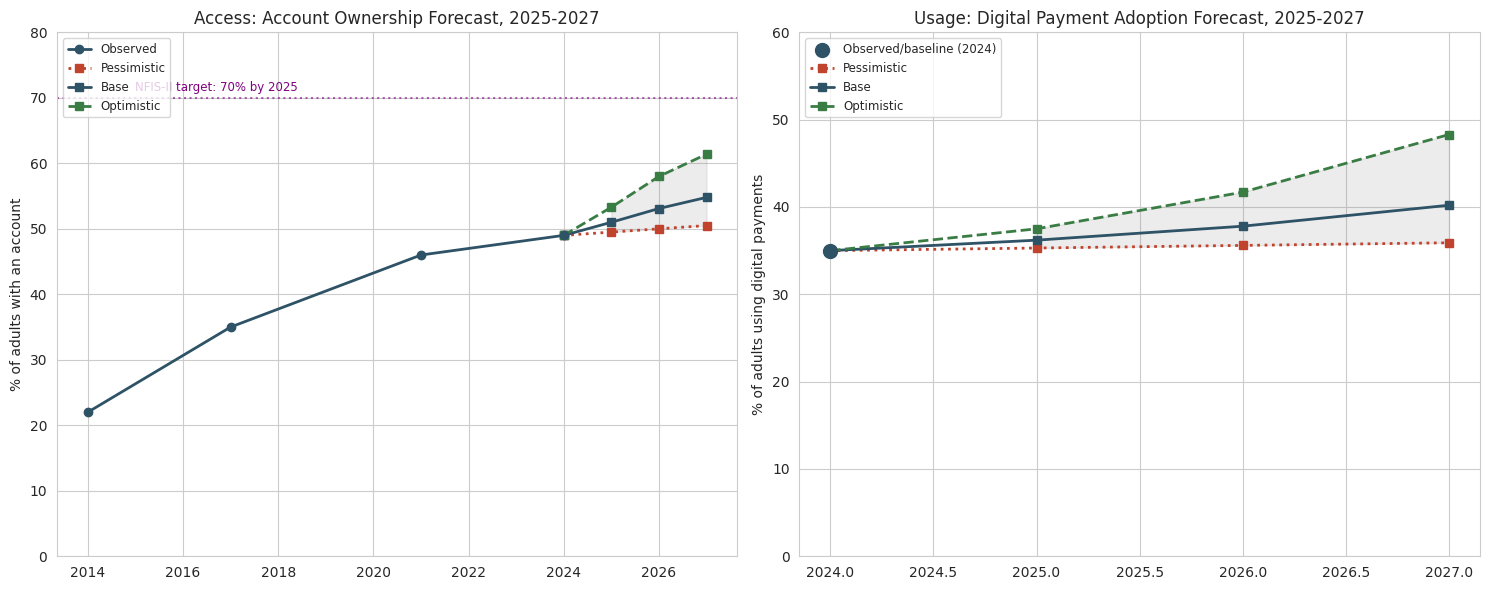

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Access panel ---
ax = axes[0]
ax.plot(acc['observation_date'].dt.year, acc['value_numeric'], marker='o', color='#2E5266', linewidth=2, label='Observed', zorder=4)
for scenario, color, style in [('pessimistic', '#C1432E', ':'), ('base', '#2E5266', '-'), ('optimistic', '#3A7D44', '--')]:
    ax.plot([2024]+list(access_forecast['year']), [49]+list(access_forecast[scenario]),
             color=color, linestyle=style, marker='s', linewidth=2, label=f'{scenario.title()}')
ax.fill_between([2025,2026,2027], access_forecast['pessimistic'], access_forecast['optimistic'], color='gray', alpha=0.15)
ax.axhline(70, color='purple', linestyle=':', alpha=0.6)
ax.annotate('NFIS-II target: 70% by 2025', (2015, 71), color='purple', fontsize=8.5)
ax.set_title("Access: Account Ownership Forecast, 2025-2027")
ax.set_ylabel("% of adults with an account")
ax.set_ylim(0, 80)
ax.legend(fontsize=8.5, loc='upper left')

# --- Usage panel ---
ax = axes[1]
ax.scatter([2024], [35.0], s=100, color='#2E5266', zorder=4, label='Observed/baseline (2024)')
for scenario, color, style in [('pessimistic', '#C1432E', ':'), ('base', '#2E5266', '-'), ('optimistic', '#3A7D44', '--')]:
    ax.plot([2024]+list(usage_forecast['year']), [35.0]+list(usage_forecast[scenario]),
             color=color, linestyle=style, marker='s', linewidth=2, label=f'{scenario.title()}')
ax.fill_between([2025,2026,2027], usage_forecast['pessimistic'], usage_forecast['optimistic'], color='gray', alpha=0.15)
ax.set_title("Usage: Digital Payment Adoption Forecast, 2025-2027")
ax.set_ylabel("% of adults using digital payments")
ax.set_ylim(0, 60)
ax.legend(fontsize=8.5, loc='upper left')

plt.tight_layout()
plt.savefig(FIG_DIR / "16_forecast_scenarios.png", bbox_inches='tight')
plt.show()

## 7. Forecast Table (Final Deliverable)

In [8]:
final_table = pd.merge(
    access_forecast.rename(columns={'pessimistic':'access_pessimistic','base':'access_base','optimistic':'access_optimistic'}),
    usage_forecast.rename(columns={'pessimistic':'usage_pessimistic','base':'usage_base','optimistic':'usage_optimistic'}),
    on='year'
)
# Attach the formal PI for Access as extra columns
final_table['access_base_80pct_PI_low'] = [round(x[2],1) for x in formal_pi]
final_table['access_base_80pct_PI_high'] = [round(x[3],1) for x in formal_pi]

print(final_table.to_string(index=False))
final_table.to_csv('../data/processed/forecast_2025_2027.csv', index=False)

 year  access_pessimistic  access_base  access_optimistic  usage_pessimistic  usage_base  usage_optimistic  access_base_80pct_PI_low  access_base_80pct_PI_high
 2025                49.5         51.0               53.3               35.3        36.2              37.5                      45.1                       63.4
 2026                50.0         53.1               58.0               35.6        37.8              41.7                      47.3                       66.6
 2027                50.5         54.8               61.4               35.9        40.2              48.3                      49.4                       69.9


## 8. Interpretation

**What the model predicts:**
- **Access** is forecast to reach **51.0-53.3% by 2025** and **54.8-61.4% by 2027** (base-to-optimistic
  range), continuing well below the NFIS-II policy target of 70% by end-2025 under every scenario,
  including optimistic. Even in the best case modeled here, Ethiopia falls roughly 9-19 percentage points
  short of that target three years past its deadline.
- **Usage** is forecast to reach **36.2-37.5% by 2025** and **40.2-48.3% by 2027**, with almost all of
  the growth beyond simple organic drift attributable to a single policy event (NDPS 2.0) whose Ethiopian
  effect is, as of this writing, entirely unobserved.

**Which events have the largest potential impact:**
- **Fayda Digital ID Rollout** is the single largest lever in the Access forecast -- contributing up to
  +7.9pp by 2027 in the optimistic case, more than the recent-trend baseline growth itself. Its national
  digital-ID infrastructure plausibly removes a genuine access barrier (KYC/onboarding friction), which is
  a more direct mechanism than a payments app launch.
- **NDPS 2.0** is the largest lever for Usage, but also the most speculative: it launched only weeks
  before this dataset's cutoff, so its entire effect in this forecast is extrapolated from India's UPI
  experience, with zero Ethiopian data to check it against (unlike Telebirr, which Task 3 showed we should
  distrust literature analogs for by a factor of ~5x).

**Key uncertainties:**
1. **The Usage forecast rests on a single 2024 baseline value and a single quantified event driver** --
   this is the single weakest link in the entire Task 4 analysis. A materially different NDPS 2.0 rollout
   speed, or a revision to the 35% vs. 21% Findex baseline conflict (Task 1/2), would move this forecast
   substantially.
2. **The 0.3x haircut applied to unvalidated event estimates is a judgment call**, not a statistically
   estimated parameter -- it is directly motivated by the one validated case from Task 3 (Telebirr
   overestimated by ~5x, i.e., actual was ~20% of literature estimate), rounded to a slightly less
   aggressive 30% to avoid overfitting a whole forecast to a single data point.
3. **Effects are combined additively** across events (per Task 3), which likely overstates the combined
   effect on Access as Telebirr, Fayda ID, and NDPS 2.0 all ramp up during the same 2025-2027 window --
   the true combined effect probably saturates below the simple sum.
4. **The formal 80% prediction interval (Section 5) is uncomfortably wide** (roughly 45-70% by 2027) --
   this is the honest cost of forecasting from 4 historical points, and is presented rather than hidden.